# descriptive.ipynb

This notebook calculated descriptive statistics in detail. The main notebook reports just a summary.

The `display_summary_table` and `plot_descriptive` functions below are called from the main notebook.

<br>
<br>

In [39]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [45]:
from IPython.display import display,Markdown #,HTML
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
import pandas as pd
import mymodule as mm

Below the previously developed `parse_data.ipynb` notebook is run. See that notebook for details.

In [46]:
%run parse_data.ipynb

df.describe()

,studytime,absences,G1,G3
count,395.000000,395.000000,395.000000,395.000000
mean,2.035443,5.708861,10.908861,10.415190
std,0.839240,8.003096,3.319195,4.581443
min,1.000000,0.000000,3.000000,0.000000
25%,1.000000,0.000000,8.000000,8.000000
50%,2.000000,4.000000,11.000000,11.000000
75%,2.000000,8.000000,13.000000,14.000000
max,4.000000,75.000000,19.000000,20.000000


To create a custom display of descriptive statistics, let's first define functions that will calculate central tendency and dispersion metrics.

Refer also to [this notebook](https://github.com/0todd0000/OpenBook-DataAnalysisPracticeInPythonAndJupyter/blob/master/Lessons/Lesson04/5-Examples/DescriptiveStatsExamples.ipynb) for details regarding how create custom descriptive statistics tables.

In [54]:
mm.display_dispersion_table

AttributeError: module 'mymodule' has no attribute 'display_dispersion_table'

<br>

Let's now assemble and display a central tendency table:

</br>

In [47]:
mm.display_central_tendency_table(num=1)

AttributeError: module 'mymodule' has no attribute 'display_central_tendency_table'

<br>

Let's repeat for a dispersion table:

</br>

In [31]:
def display_dispersion_table(num=1):
    display_title('Dispersion summary statistics.', pref='Table', num=num, center=False)
    df_dispersion         = df.apply(lambda x: dispersion(x), axis=0)
    row_labels_dispersion = 'st.dev.', 'min', 'max', 'range', '25th', '75th', 'IQR'
    df_dispersion.index   = row_labels_dispersion
    display( df_dispersion )

mm.display_dispersion_table(num=2)


AttributeError: module 'mymodule' has no attribute 'display_dispersion_table'

Let's save the variables in easier-to-use variable names:

In [7]:
y    = df['G3']
G1 = df['G1']
st = df['studytime']
ab = df['absences']

Let's create scatterplots for the DV (quality) vs. each of the three IVs (acid, density, sugar):

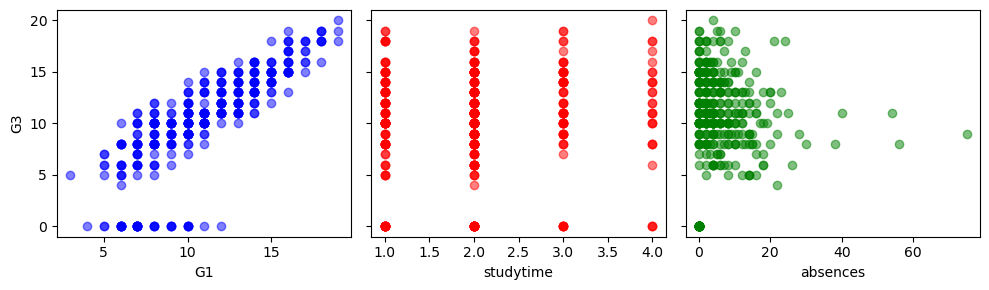

In [8]:

fig,axs = plt.subplots( 1, 3, figsize=(10,3), tight_layout=True )
axs[0].scatter( G1, y, alpha=0.5, color='b' )
axs[1].scatter( st, y, alpha=0.5, color='r' )
axs[2].scatter( ab, y, alpha=0.5, color='g' )

xlabels = 'G1', 'studytime', 'absences' 
[ax.set_xlabel(s) for ax,s in zip(axs,xlabels)]
axs[0].set_ylabel('G3')
[ax.set_yticklabels([])  for ax in axs[1:]]
plt.show()

Next let's add regression lines and correlation coefficients to each plot:

In [9]:
def corrcoeff(x, y):
    r = np.corrcoef(x, y)[0,1]
    return r

def plot_regression_line(ax, x, y, **kwargs):
    a,b   = np.polyfit(x, y, deg=1)
    x0,x1 = min(x), max(x)
    y0,y1 = a*x0 + b, a*x1 + b
    ax.plot([x0,x1], [y0,y1], **kwargs)


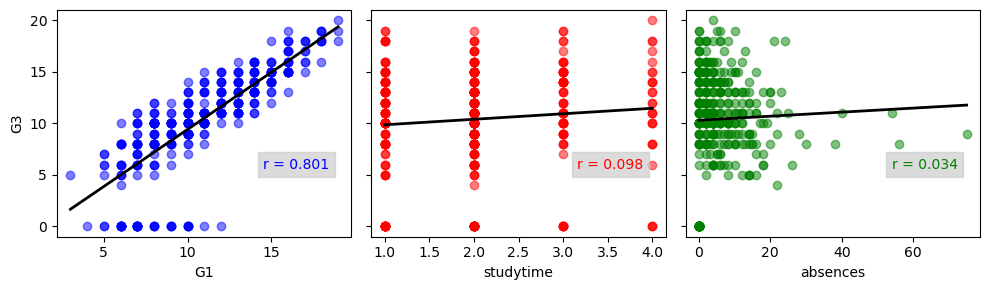

In [10]:
    
fig,axs = plt.subplots( 1, 3, figsize=(10,3), tight_layout=True )
ivs     = [G1, st, ab]
colors  = 'b', 'r', 'g'
for ax,x,c in zip(axs, ivs, colors):
    ax.scatter( x, y, alpha=0.5, color=c )
    plot_regression_line(ax, x, y, color='k', ls='-', lw=2)
    r   = corrcoeff(x, y)
    ax.text(0.7, 0.3, f'r = {r:.3f}', color=c, transform=ax.transAxes, bbox=dict(color='0.8', alpha=0.7))

xlabels = 'G1', 'studytime', 'absences' 
[ax.set_xlabel(s) for ax,s in zip(axs,xlabels)]
axs[0].set_ylabel('G3')
[ax.set_yticklabels([])  for ax in axs[1:]]
plt.show()

G1 and G3 show a strong correlation (When G1 is high, G3 also tends to be high), but no correlation is observed between the others.

However, in the sugar data (right panel above) it appears that there may be opposite trends for low-quality wines (quality <= 5) and high-quality wines (quality > 5).  Let's plot quality vs. sugar separately for the low- and high-quality groups, along with linear regression trends.

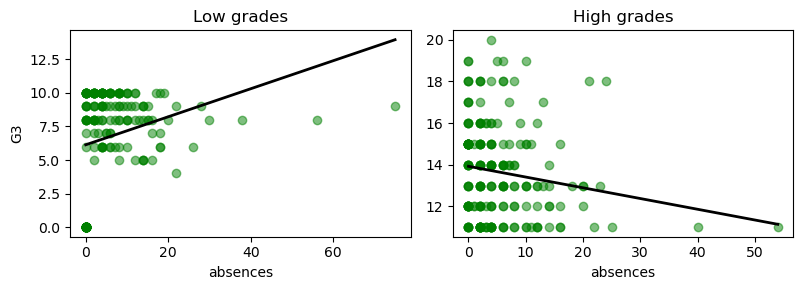

In [11]:
i_low     = y <= 10
i_high    = y > 10

fig,axs = plt.subplots( 1, 2, figsize=(8,3), tight_layout=True )
i       = [ab]
for ax,i in zip(axs, [i_low, i_high]):
    ax.scatter( ab[i], y[i], alpha=0.5, color='g' )
    plot_regression_line(ax, ab[i], y[i], color='k', ls='-', lw=2)
[ax.set_xlabel('absences')  for ax in axs] 
axs[0].set_title('Low grades')
axs[0].set_ylabel('G3')
axs[1].set_title('High grades')
plt.show()

The linear trend lines in the figures above appear to be opposite to the visual patterns:

- G3 appears to increase with absences in low grades
- G3 appears to descrease with absences in high grades

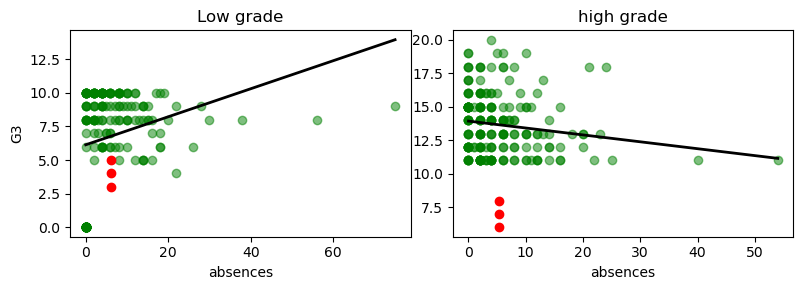

In [12]:
fig,axs = plt.subplots( 1, 2, figsize=(8,3), tight_layout=True )
for ax,i in zip(axs, [i_low, i_high]):
    ax.scatter( ab[i], y[i], alpha=0.5, color='g' )
    plot_regression_line(ax, ab[i], y[i], color='k', ls='-', lw=2)
[axs[0].plot(ab[i_low].mean(), q, 'ro')  for q in [3,4,5]]
[axs[1].plot(ab[i_high].mean(), q, 'ro')  for q in [6,7,8]]
[ax.set_xlabel('absences')  for ax in axs] 
axs[0].set_title('Low grade')
axs[0].set_ylabel('G3')
axs[1].set_title('high grade')
plt.show()


This shows that each average is nearly the same.
Let's now assemble all results into a single figure for reporting purposes:

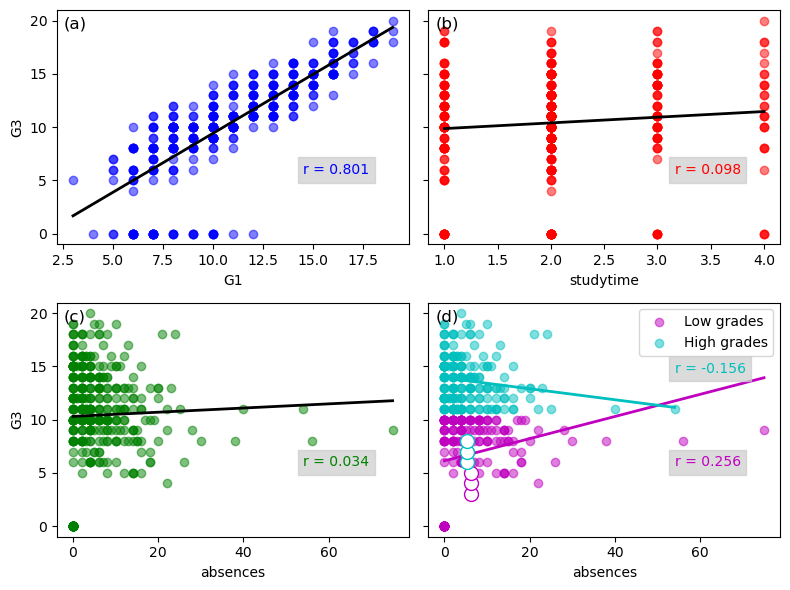

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Correlations amongst main variables.</span></p><br><br>

In [13]:
def plot_descriptive():
    
    fig,axs = plt.subplots( 2, 2, figsize=(8,6), tight_layout=True )
    ivs     = [G1, st, ab]
    colors  = 'b', 'r', 'g'
    for ax,x,c in zip(axs.ravel(), ivs, colors):
        ax.scatter( x, y, alpha=0.5, color=c )
        plot_regression_line(ax, x, y, color='k', ls='-', lw=2)
        r   = corrcoeff(x, y)
        ax.text(0.7, 0.3, f'r = {r:.3f}', color=c, transform=ax.transAxes, bbox=dict(color='0.8', alpha=0.7))

    xlabels = 'G1', 'studytime', 'absences' 
    [ax.set_xlabel(s) for ax,s in zip(axs.ravel(),xlabels)]
    [ax.set_ylabel('G3') for ax in axs[:,0]]
    [ax.set_yticklabels([])  for ax in axs[:,1]]


    ax       = axs[1,1]
    i_low    = y <= 10
    i_high   = y > 10
    fcolors  = 'm', 'c'
    labels   = 'Low grades', 'High grades'
    q_groups = [[3,4,5], [6,7,8]]
    ylocs    = 0.3, 0.7
    for i,c,s,qs,yloc in zip([i_low, i_high], fcolors, labels, q_groups, ylocs):
        ax.scatter( ab[i], y[i], alpha=0.5, color=c, facecolor=c, label=s )
        plot_regression_line(ax, ab[i], y[i], color=c, ls='-', lw=2)
        [ax.plot(ab[i].mean(), q, 'o', color=c, mfc='w', ms=10)  for q in qs]
        r   = corrcoeff(ab[i], y[i])
        ax.text(0.7, yloc, f'r = {r:.3f}', color=c, transform=ax.transAxes, bbox=dict(color='0.8', alpha=0.7))

    ax.legend()
    ax.set_xlabel('absences')

    panel_labels = 'a', 'b', 'c', 'd'
    [ax.text(0.02, 0.92, f'({s})', size=12, transform=ax.transAxes)  for ax,s in zip(axs.ravel(), panel_labels)]
    plt.show()
    
    display_title('Correlations amongst main variables.', pref='Figure', num=1)

    
plot_descriptive()